In [ ]:
import sympy
from sympy import symbols, sin, cos
from sympy import Matrix, nsolve
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

from scipy.optimize import minimize

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5//serverfolder//expctl//src")

import xarray as xr

from expctl.servers.servoaligner.solver_plotter import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iteration_actuator import iteration_actuator
from expctl.servers.servoaligner.iterator_compute import angle_calc_single

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from smbus2 import SMBus,i2c_msg
import MCP342x

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset
from expctl.servers.servoaligner.servo_util import create_zigzag_X, format_para,a2p,r2nd,r2nr,ndmodr,nrselr,nrmodr,nraddr,compose_para
from expctl.servers.servoaligner.fit_gaussian import gaussian_2d,gaussian_2d_smooth_heaviside,fit_and_plot,fit_gaussian_2d,fit_gaussian_2d_smooth_heaviside,fit_and_plot_smooth_heaviside,popt_get_mu_cov,statistics_skewness
from expctl.servers.servoaligner.motor_scan import motor_1d_scan,motor_2d_scan
from expctl.servers.servoaligner.servo_const import A_X_XDOT_MASK,A_Y_YDOT_MASK,A_X_Y_MASK,A_XDOT_YDOT_MASK,A_POS_ALL_MASK,B_X_XDOT_MASK,B_Y_YDOT_MASK,B_X_Y_MASK,B_XDOT_YDOT_MASK,B_POS_ALL_MASK,POS_ALL_MASK, posmask2str
#from expctl.servers.servoaligner.pd import MCP3424_fiber
from expctl.servers.servoaligner.step_optimize import step_optimize

In [27]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])

i2cbus = SMBus(1)
MCP3424_fiber=MCP342x.MCP342x(i2cbus, 0x68, device='MCP3424', channel=0, gain=1, resolution=12, continuous_mode=False, scale_factor=1.0, offset=0.0)

2025-03-06 17:15:39,464 - INFO - Succeeded to open the port
2025-03-06 17:15:39,467 - INFO - Succeeded to change the baudrate
2025-03-06 17:15:39,473 - INFO - Servo 1x: SCServo acc set!
2025-03-06 17:15:39,479 - INFO - Servo 1x: SCServo speed set!
2025-03-06 17:15:39,485 - INFO - Servo 1x: SCServo acc set!
2025-03-06 17:15:39,491 - INFO - Servo 1x: SCServo speed set!
2025-03-06 17:15:39,501 - INFO - Servo 1y: SCServo acc set!
2025-03-06 17:15:39,506 - INFO - Servo 1y: SCServo speed set!
2025-03-06 17:15:39,511 - INFO - Servo 1y: SCServo acc set!
2025-03-06 17:15:39,516 - INFO - Servo 1y: SCServo speed set!
2025-03-06 17:15:39,525 - INFO - Servo 2x: SCServo acc set!
2025-03-06 17:15:39,530 - INFO - Servo 2x: SCServo speed set!
2025-03-06 17:15:39,535 - INFO - Servo 2x: SCServo acc set!
2025-03-06 17:15:39,540 - INFO - Servo 2x: SCServo speed set!
2025-03-06 17:15:39,549 - INFO - Servo 2y: SCServo acc set!
2025-03-06 17:15:39,554 - INFO - Servo 2y: SCServo speed set!
2025-03-06 17:15:39,

In [ ]:
servos.home()
servos.torques_disable()

2025-03-05 18:27:53,825 - INFO - going home


In [ ]:
servos.set_zero()

2025-03-03 17:54:06,389 - INFO - Setting Zero
2025-03-03 17:54:06,401 - INFO - Servo 1x: SCServo zero set!
2025-03-03 17:54:06,437 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,472 - INFO - Servo 1y: result [TxRxResult] Incorrect status packet!
2025-03-03 17:54:06,473 - INFO - Servo 1y: SCServo zero set!
2025-03-03 17:54:06,484 - INFO - Servo 2x: SCServo zero set!
2025-03-03 17:54:06,495 - INFO - Servo 2y: SCServo zero set!
2025-03-03 17:54:06,531 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,537 - ERROR - Servo 3x: Read not sucessful!
2025-03-03 17:54:06,573 - INFO - Servo 3x: result [TxRxResult] Incorrect status packet!
2025-03-03 17:54:06,574 - INFO - Servo 3x: SCServo zero set!
2025-03-03 17:54:06,609 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,615 - ERROR - Servo 3y: Read not sucessful!
2025-03-03 17:54:06,621 - ERROR - Servo 3y: Read not sucessful!
2025-03-03 17:54:06,657 - INFO - Servo 3y: result [TxRxResult]

In [12]:
#servos.set_zero()
servos.torques_disable()

In [3]:
servos.home()
print(MCP3424_fiber.convert_and_read())

2025-03-07 13:53:49,900 - INFO - going home


1.04


In [11]:
print(MCP3424_fiber.convert_and_read())
servos.get_angle()

1.04


array([-0.43945312, -0.43945312, -0.43945312, -0.61523438,  0.        ,
        0.        ,  0.        ,  0.        ])

# Angle sweeping

In [2]:
from itertools import product

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5//serverfolder//expctl//src")

import xarray as xr

from expctl.servers.servoaligner.solver_plotter_np import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iteration_actuator import iteration_actuator, single_actuator_minimize
from expctl.servers.servoaligner.iterator_compute import angle_calc_single, scan_xarray_gen, scan_xarray_gen_knobs

from scipy.optimize import minimize

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from functools import partial

from smbus2 import SMBus,i2c_msg
import MCP342x

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset

In [3]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])
i2cbus = SMBus(1)
MCP3424_fiber=MCP342x.MCP342x(i2cbus, 0x68, device='MCP3424', channel=0, gain=1, resolution=12, continuous_mode=False, scale_factor=1.0, offset=0.0)

2025-03-07 10:48:50,186 - INFO - Succeeded to open the port
2025-03-07 10:48:50,189 - INFO - Succeeded to change the baudrate
2025-03-07 10:48:50,194 - INFO - Servo 1x: SCServo acc set!
2025-03-07 10:48:50,200 - INFO - Servo 1x: SCServo speed set!
2025-03-07 10:48:50,205 - INFO - Servo 1x: SCServo acc set!
2025-03-07 10:48:50,210 - INFO - Servo 1x: SCServo speed set!
2025-03-07 10:48:50,219 - INFO - Servo 1y: SCServo acc set!
2025-03-07 10:48:50,224 - INFO - Servo 1y: SCServo speed set!
2025-03-07 10:48:50,229 - INFO - Servo 1y: SCServo acc set!
2025-03-07 10:48:50,234 - INFO - Servo 1y: SCServo speed set!
2025-03-07 10:48:50,243 - INFO - Servo 2x: SCServo acc set!
2025-03-07 10:48:50,248 - INFO - Servo 2x: SCServo speed set!
2025-03-07 10:48:50,253 - INFO - Servo 2x: SCServo acc set!
2025-03-07 10:48:50,258 - INFO - Servo 2x: SCServo speed set!
2025-03-07 10:48:50,267 - INFO - Servo 2y: SCServo acc set!
2025-03-07 10:48:50,272 - INFO - Servo 2y: SCServo speed set!
2025-03-07 10:48:50,

In [1]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.205
fl2 = 0.145
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=-2e-4

MOT_pos_2=0
Cav_pos_2=2e-4

MOT_pos_rel = 0.22
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

In [2]:
solver_0=Optical_system_solver()
#scan_xr=scan_xarray_gen(var_str_list=['fl1','fl2','MOT_pos_1','MOT_pos_2'], range_list=[1e-2, 1e-2, 2e-4, 2e-4], num_list=[5,5,10,10], start_value_list=[fl1, MOT_pos_1, MOT_pos_2])
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['fl1','MOT_pos_rel','Cav_pos_1'], range_list=[1e-2, 4e-2, 4e-4], num_list=[5,20,20], start_value_list=[fl1, MOT_pos_rel, Cav_pos_1], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['MOT_pos_rel','Cav_pos_2'], range_list=[4e-2, 4e-4], num_list=[20,20], start_value_list=[MOT_pos_rel, Cav_pos_2], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['MOT_pos_rel','Cav_pos_1','Cav_pos_2'], range_list=[2e-2, 1e-3, 1e-3], num_list=[5,10,10], start_value_list=[MOT_pos_rel,Cav_pos_1, Cav_pos_2], params=params)
scan_xr=scan_xarray_gen(solver_0, var_str_list=['fl1','fl2','Cav_pos_1','Cav_pos_2'], range_list=[1e-2, 1e-2, 4e-4, 4e-4], num_list=[5,5,10,10], start_value_list=[fl1, fl2, Cav_pos_1, Cav_pos_2], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['dy0','MOT_pos_rel','Cav_pos_1','Cav_pos_2'], range_list=[2e-2, 2e-2, 4e-4, 4e-4], num_list=[5,5,10,10], start_value_list=[dy0,MOT_pos_rel,Cav_pos_1, Cav_pos_2], params=params)
scan_xr

NameError: name 'Optical_system_solver' is not defined

In [101]:
ds=iteration_actuator(servos, MCP3424_fiber, scan_xr)

100%|██████████| 2500/2500 [45:48<00:00,  1.10s/it] 
2025-03-06 16:32:53,077 - INFO - going home


1.04


In [103]:
ds

<xarray.Dataset>
Dimensions:      (fl1: 5, fl2: 5, Cav_pos_1: 10, Cav_pos_2: 10, knobs: 8)
Coordinates:
  * fl1          (fl1) float64 0.19 0.195 0.2 0.205 0.21
  * fl2          (fl2) float64 0.14 0.145 0.15 0.155 0.16
  * Cav_pos_1    (Cav_pos_1) float64 -0.0004 -0.0003111 ... 0.0003111 0.0004
  * Cav_pos_2    (Cav_pos_2) float64 -0.0004 -0.0003111 ... 0.0003111 0.0004
  * knobs        (knobs) <U6 'Mrr1_x' 'Mrr1_y' 'Mrr2_x' ... 'Mrr4_x' 'Mrr4_y'
Data variables:
    knob_angles  (fl1, fl2, Cav_pos_1, Cav_pos_2, knobs) float64 -280.3 ... -...
    data         (fl1, fl2, Cav_pos_1, Cav_pos_2) float64 0.033 0.037 ... 0.001

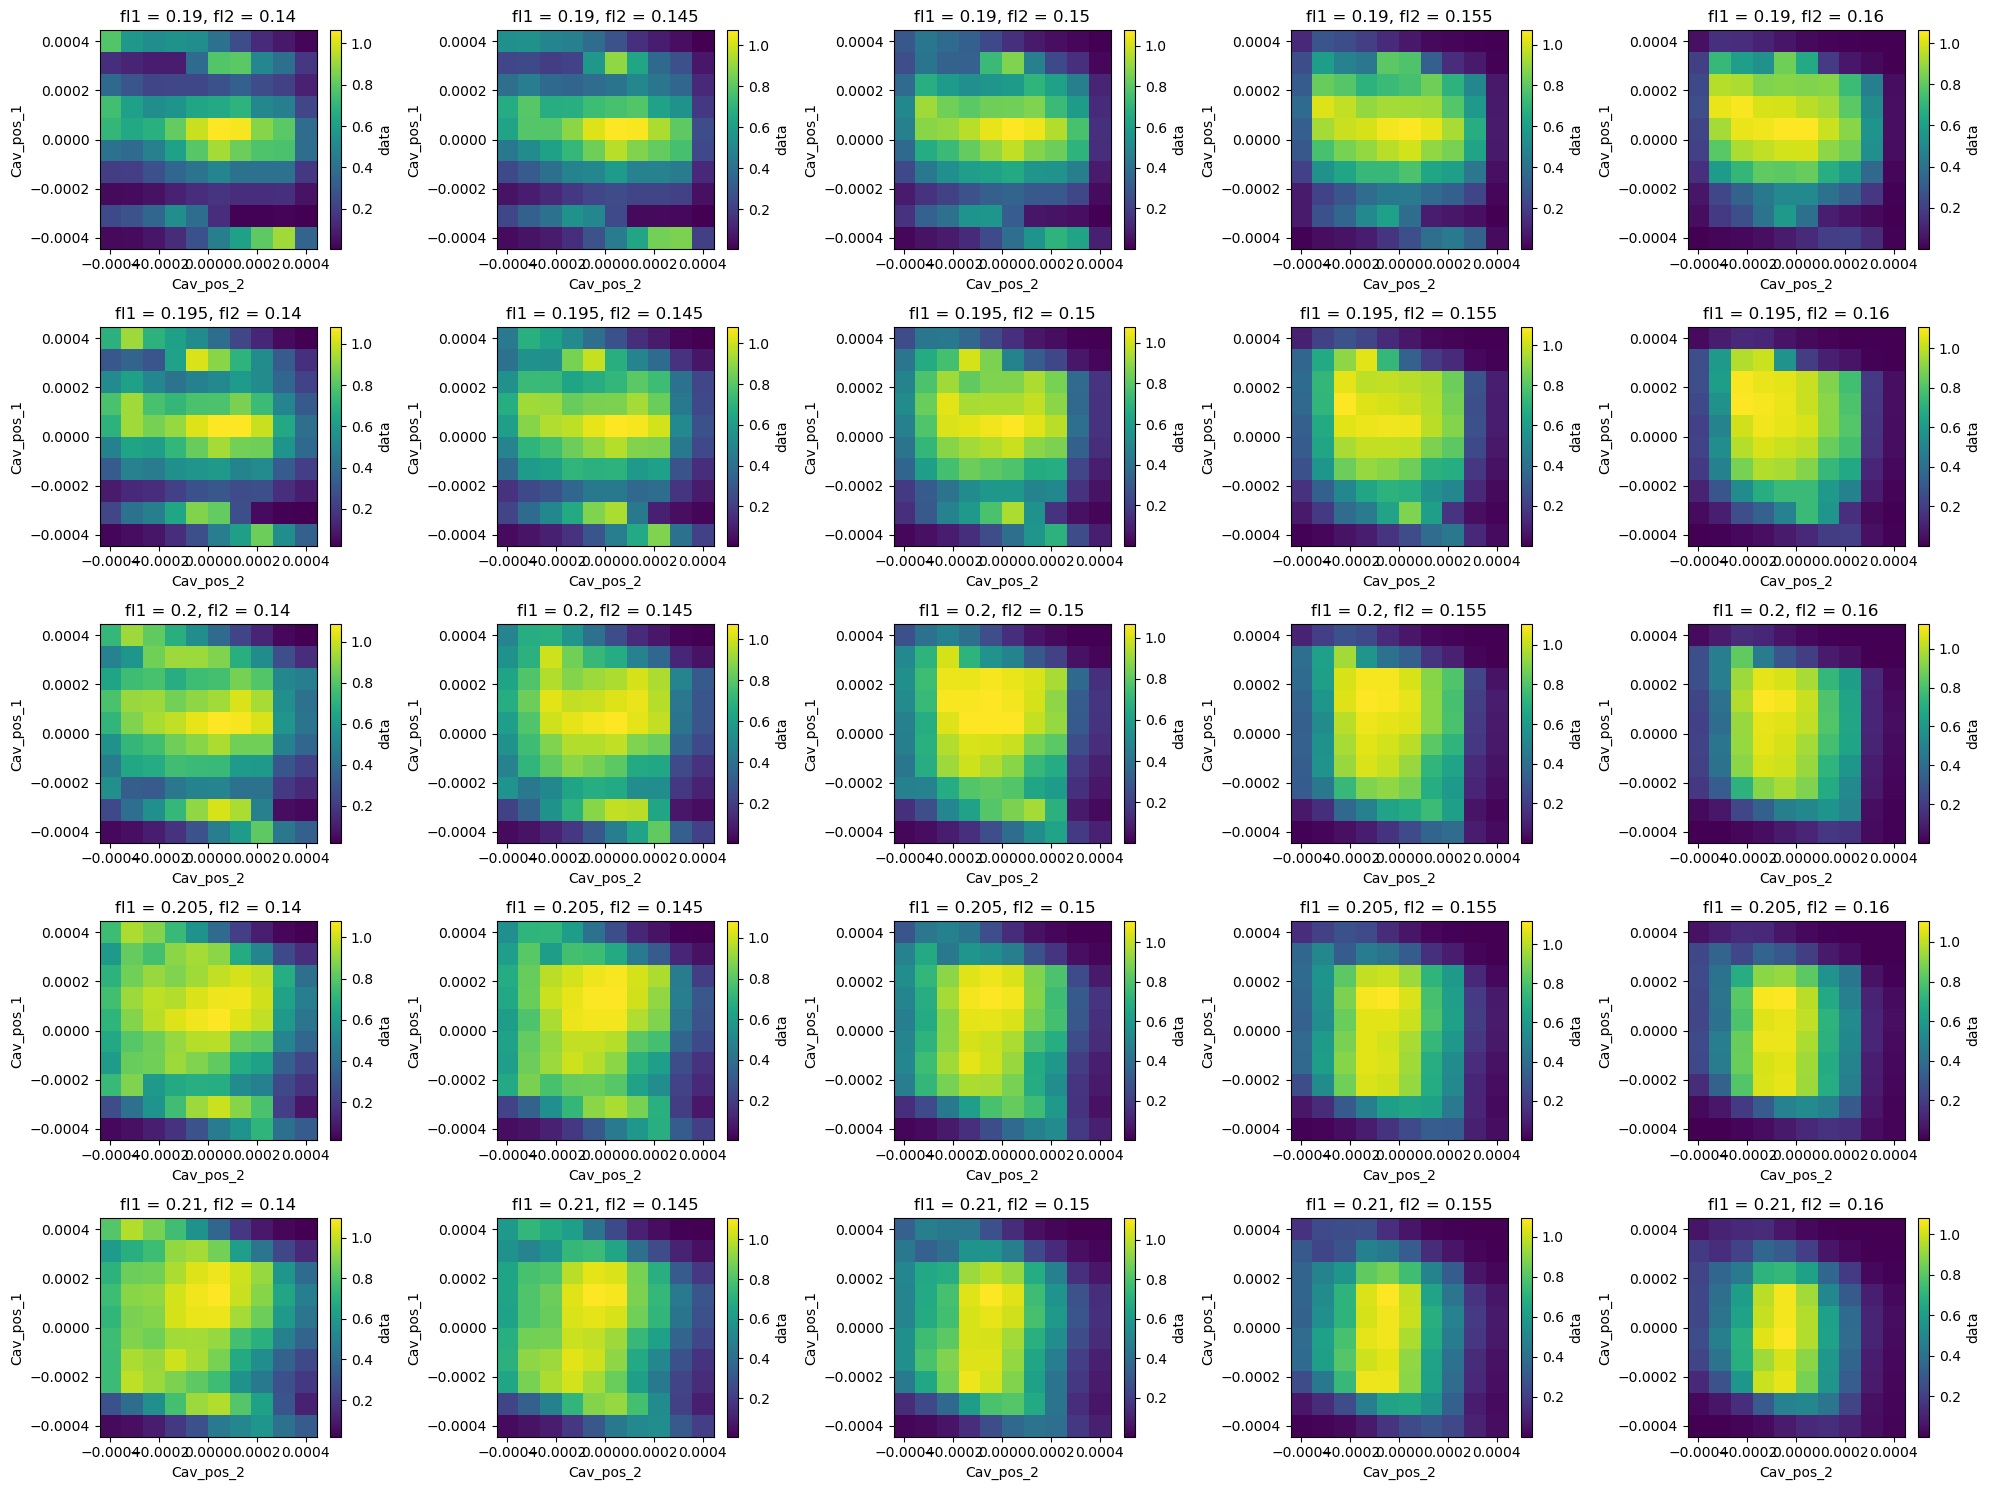

In [102]:
fig,axs=plt.subplots(5,5,figsize=(20,15)) 
for i in range(5):
    for j in range(5):
        ds['data'].isel(fl1=i, fl2=j).plot(ax=axs[i,j])
fig.tight_layout()
plt.show()

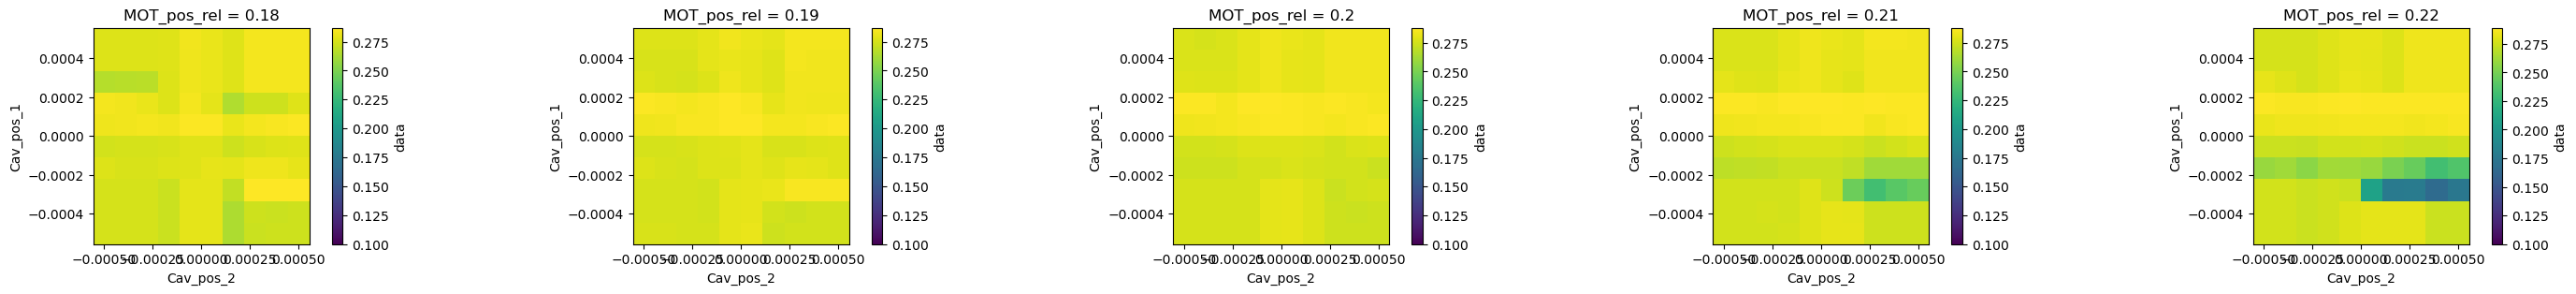

In [75]:
fig,axs=plt.subplots(1,5,figsize=(36,3)) 
for i in range(5):
    ds['data'].isel(MOT_pos_rel=i).plot(ax=axs[i], vmin=0.10)
    axs[i].set_aspect('equal')
#fig.tight_layout()
plt.show()

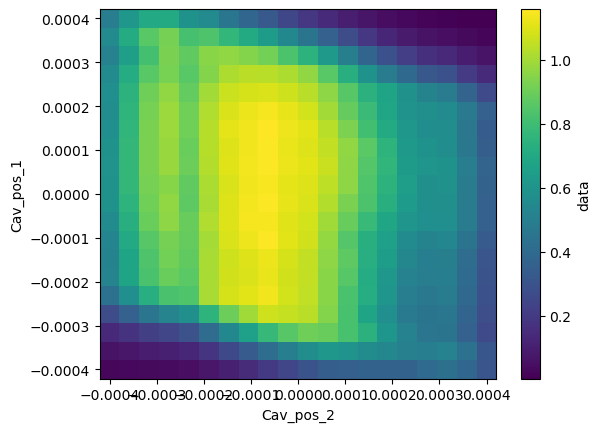

In [15]:
ds['data'].plot()

In [29]:
ds.to_netcdf("data0306_1.nc")

In [ ]:
ds=xr.open_dataset("data0304_3.nc")
ds['data'].plot()

In [149]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=-5e-4

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.20
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

knob_deg_list=angle_calc_single(params)
print(knob_deg_list)

servos.set_angle(knob_deg_list)
print('fiber power:',MCP3424_fiber.convert_and_read())

solver_0=Optical_system_solver()
scan_xr_knob=scan_xarray_gen_knobs(solver_0, var_str_list=['servo_3x','servo_4x'], range_list=[50,50], offset_list=[-50,-50], num_list=[20,20], knob_deg_list=knob_deg_list)

scan_xr_knob

[-343.5067891076635, 0.0, -343.50678886894315, 0.0, -187.54489013927883, 0.0, -244.98237181993755, 0.0]
fiber power: 0.005


<xarray.DataArray (servo_3x: 20, servo_4x: 20, knobs: 8)>
array([[[-343.50678911,    0.        , -343.50678887, ...,
            0.        , -344.98237182,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -339.71921393,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -334.45605603,    0.        ],
        ...,
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -255.50868761,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -250.24552971,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -244.98237182,    0.        ]],

       [[-343.50678911,    0.        , -343.50678887, ...,
            0.        , -344.98237182,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -339.71921393,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -334.45605603,    0.        ],
...
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -255.50868761,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -250.24552971,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -244.98237182,    0.        ]],

       [[-343.50678911,    0.        , -343.50678887, ...,
            0.        , -344.98237182,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -339.71921393,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -334.45605603,    0.        ],
        ...,
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -255.50868761,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -250.24552971,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -244.98237182,    0.        ]]])
Coordinates:
  * servo_3x  (servo_3x) float64 -287.5 -282.3 -277.0 ... -198.1 -192.8 -187.5
  * servo_4x  (servo_4x) float64 -345.0 -339.7 -334.5 ... -255.5 -250.2 -245.0
  * knobs     (knobs) <U6 'Mrr1_x' 'Mrr1_y' 'Mrr2_x' ... 'Mrr4_x' 'Mrr4_y'

In [5]:
ds_knob=iteration_actuator(servos, MCP3424_fiber, scan_xr_knob)

100%|██████████| 400/400 [02:00<00:00,  3.33it/s]
2025-03-06 17:32:53,314 - INFO - going home


1.035


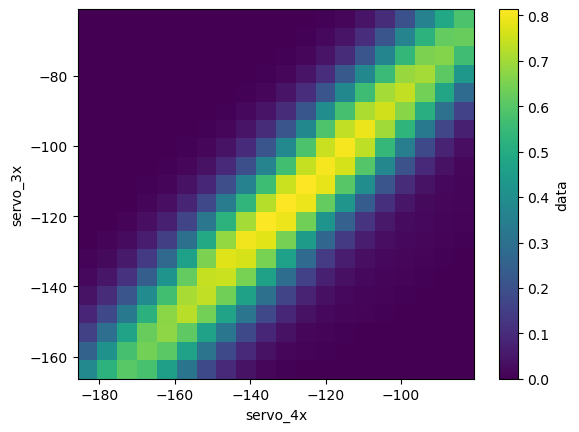

In [6]:
ds_knob['data'].plot()

In [19]:
knob_deg_list=[-116.6010304545216, 137.33043067108903, -116.60102852809291, -137.33042837948153, -121, 61.4985211137023, -134, -84.47311247400913]
servos.set_angle(knob_deg_list)
print('fiber power:',MCP3424_fiber.convert_and_read())

solver_0=Optical_system_solver()
scan_xr_knob=scan_xarray_gen_knobs(solver_0, var_str_list=['servo_3y','servo_4y'], range_list=[50,50], offset_list=[0,0], num_list=[20,20], knob_deg_list=knob_deg_list)

scan_xr_knob

fiber power: 0.8270000000000001


<xarray.DataArray (servo_3y: 20, servo_4y: 20, knobs: 8)>
array([[[-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        , -134.47311247],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        , -129.20995458],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        , -123.94679668],
        ...,
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        ,  -44.99942826],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        ,  -39.73627037],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        ,  -34.47311247]],

       [[-116.60103045,  137.33043067, -116.60102853, ...,
           16.76167901, -134.        , -134.47311247],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           16.76167901, -134.        , -129.20995458],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           16.76167901, -134.        , -123.94679668],
...
        [-116.60103045,  137.33043067, -116.60102853, ...,
          106.23536322, -134.        ,  -44.99942826],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          106.23536322, -134.        ,  -39.73627037],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          106.23536322, -134.        ,  -34.47311247]],

       [[-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        , -134.47311247],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        , -129.20995458],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        , -123.94679668],
        ...,
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        ,  -44.99942826],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        ,  -39.73627037],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        ,  -34.47311247]]])
Coordinates:
  * servo_3y  (servo_3y) float64 11.5 16.76 22.02 27.29 ... 101.0 106.2 111.5
  * servo_4y  (servo_4y) float64 -134.5 -129.2 -123.9 ... -45.0 -39.74 -34.47
  * knobs     (knobs) <U6 'Mrr1_x' 'Mrr1_y' 'Mrr2_x' ... 'Mrr4_x' 'Mrr4_y'

In [20]:
ds_knob=iteration_actuator(servos, MCP3424_fiber, scan_xr_knob)

100%|██████████| 400/400 [01:54<00:00,  3.49it/s]
2025-03-06 17:45:30,470 - INFO - going home


1.039


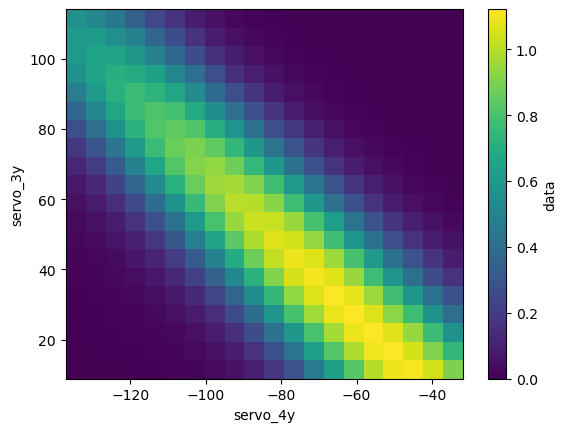

In [21]:
ds_knob['data'].plot()

minimizer

In [1]:
from itertools import product

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5//serverfolder//expctl//src")

import xarray as xr

from expctl.servers.servoaligner.solver_plotter_np import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iteration_actuator import iteration_actuator, actuator_minimize
from expctl.servers.servoaligner.iterator_compute import angle_calc_single, scan_xarray_gen, scan_xarray_gen_knobs

from scipy.optimize import minimize

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from functools import partial

from smbus2 import SMBus,i2c_msg
import MCP342x

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset

In [2]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])
i2cbus = SMBus(1)
MCP3424_fiber=MCP342x.MCP342x(i2cbus, 0x68, device='MCP3424', channel=0, gain=1, resolution=12, continuous_mode=False, scale_factor=1.0, offset=0.0)

2025-03-07 13:53:38,520 - INFO - Succeeded to open the port
2025-03-07 13:53:38,524 - INFO - Succeeded to change the baudrate
2025-03-07 13:53:38,529 - INFO - Servo 1x: SCServo acc set!
2025-03-07 13:53:38,535 - INFO - Servo 1x: SCServo speed set!
2025-03-07 13:53:38,540 - INFO - Servo 1x: SCServo acc set!
2025-03-07 13:53:38,545 - INFO - Servo 1x: SCServo speed set!
2025-03-07 13:53:38,554 - INFO - Servo 1y: SCServo acc set!
2025-03-07 13:53:38,559 - INFO - Servo 1y: SCServo speed set!
2025-03-07 13:53:38,564 - INFO - Servo 1y: SCServo acc set!
2025-03-07 13:53:38,569 - INFO - Servo 1y: SCServo speed set!
2025-03-07 13:53:38,579 - INFO - Servo 2x: SCServo acc set!
2025-03-07 13:53:38,584 - INFO - Servo 2x: SCServo speed set!
2025-03-07 13:53:38,589 - INFO - Servo 2x: SCServo acc set!
2025-03-07 13:53:38,594 - INFO - Servo 2x: SCServo speed set!
2025-03-07 13:53:38,603 - INFO - Servo 2y: SCServo acc set!
2025-03-07 13:53:38,608 - INFO - Servo 2y: SCServo speed set!
2025-03-07 13:53:38,

In [3]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=3e-4

MOT_pos_2=0
Cav_pos_2=3e-4

MOT_pos_rel = 0.20
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

knob_deg_list=angle_calc_single(params)
print(knob_deg_list)

servos.set_angle(knob_deg_list)
print('fiber power:',MCP3424_fiber.convert_and_read())

[236.7304371518977, 206.06235716855468, 236.73035532806932, -206.06232362862133, 129.23462338260086, 92.26598114049317, 168.8928895564789, -126.72791937392036]
fiber power: 0.276


In [4]:
result_deg_list = actuator_minimize(servos, MCP3424_fiber, knob_deg_list)

-0.273
-0.20730000000000004
-0.3886
-0.4673999999999999
-0.6218
-0.6868
-0.7034
-0.7560999999999999
-0.28300000000000003
-0.182
-0.7873
-0.9153
-0.9810000000000001
-0.7897000000000001
-0.9484000000000001
-0.8774
-0.9885000000000002
-0.7653999999999999
-1.0187
-0.9773
-1.0031
-0.9835
-1.0065
Optimization terminated successfully.
         Current function value: -1.018700
         Iterations: 12
         Function evaluations: 23
-1.0145
-0.9481000000000002
-0.9816999999999998
-1.0133000000000003
-1.068
-1.0812000000000002
-0.9114000000000001
-1.0548
-1.1034000000000002
-1.1042
-1.0788999999999997
-1.0995000000000001
-1.0595
-1.1001999999999998
-1.1059999999999999
-1.0802
-1.0715999999999997
-1.1088
-1.0984000000000003
-1.1103
Optimization terminated successfully.
         Current function value: -1.110300
         Iterations: 10
         Function evaluations: 20


In [151]:
# func=partial(single_actuator_minimize, servos=servos, MCP3424_fiber=MCP3424_fiber, servos_name_list=['servo_3x','servo_4x'], knob_deg_list=knob_deg_list)

points = []
values = []

# def wrapper(x):
#     val = single_actuator_minimize(deg_list=x, servos=servos, MCP3424_fiber=MCP3424_fiber, servos_name_list=['servo_3x','servo_4x'], knob_deg_list=knob_deg_list)
#     points.append(x)
#     values.append(val)
#     return val

def wrapper_x(par, knob_deg_list):

    x = par[0]
    y = par[1]
    val = single_actuator_minimize(deg_list=diag_forw(x,y), servos=servos, MCP3424_fiber=MCP3424_fiber, servos_name_list=['servo_3x','servo_4x'], knob_deg_list=knob_deg_list)
    points.append(par)
    values.append(val)
    return val

def wrapper_y(par, knob_deg_list):
    print(knob_deg_list)
    x = par[0]
    y = par[1]
    val = single_actuator_minimize(deg_list=anti_forw(x,y), servos=servos, MCP3424_fiber=MCP3424_fiber, servos_name_list=['servo_3y','servo_4y'], knob_deg_list=knob_deg_list)
    points.append(par)
    values.append(val)
    return val


# minimize(func, [-100, -100], method='Nelder-Mead', bounds=[(-180, 180), (-180, 180)], callback=cb,
#          options={'xatol': 5e-1, 'fatol': 1e-1, 'disp': True, 'maxiter': 50})

# minimize(wrapper, [0, 0], method='Nelder-Mead', bounds=[(-180, 180), (-180, 180)], callback=cb,
#          options={'xatol': 5e-1, 'fatol': 1e-2, 'disp': True, 'maxiter': 50})

# minimize(wrapper, [0, 0], method='CG', bounds=[(-180, 180), (-180, 180)], callback=cb,
#          options={'eps': 10.0, 'disp': True, 'maxiter': 50})

# minimize(wrapper, [0, 0], method='BFGS', bounds=[(-180, 180), (-180, 180)],
#          options={'xrtol': 1e-2, 'eps': 2.0, 'disp': True, 'maxiter': 50})

# minimize(wrapper, [0, 0], method='COBYLA', bounds=[(-180, 180), (-180, 180)],
#          options={'f_target': -0.8, 'feasibility_tol': 0.05, 'initial_tr_radius': 3.0, 'disp': True, 'maxiter': 50})

# res = direct(wrapper, bounds=[(-180, 180), (-180, 180)], eps=0.05, f_min= -0.8, f_min_rtol=0.05, maxiter=50)
# res = direct(wrapper, bounds=[(-180, 180), (-40, 40)], eps=0.05, f_min= -0.8, f_min_rtol=0.05, maxiter=50)

#initial_simplex: array_like of shape (N + 1, N)
initial_simplex = np.array([[0, 0], [10, 0], [0, 3]])

# res = minimize(wrapper_x, [0, 0], method='Nelder-Mead', bounds=[(-180, 180), (-40, 40)],
#          options={'initial_simplex': initial_simplex, 'xatol': 5.0, 'fatol': 1e-1, 'disp': True, 'maxiter': 20})

res = minimize(wrapper_x, [0, 0], method='Nelder-Mead', bounds=[(-180, 180), (-40, 40)], args=(knob_deg_list),
         options={'initial_simplex': initial_simplex, 'xatol': 5.0, 'fatol': 1e-1, 'disp': True, 'maxiter': 20})

# print('fiber power:',MCP3424_fiber.convert_and_read())

-0.012
-0.009999999999999998
-0.022
-0.030000000000000006
-0.05890000000000001
-0.12910000000000005
-0.3479
-0.6109000000000001
-0.9418
-0.4431
-0.0637
-0.7732
-0.40630000000000005
-0.7091999999999998
-0.7209999999999999
-0.8251000000000002
-0.9882
-1.0436999999999999
-0.9469000000000001
-0.9367000000000001
-0.958
-0.9433
-0.9762999999999998
-1.0492
-1.0609
-1.0876
-1.0533000000000001
-1.0339
-1.0725
-1.0718
-1.0802999999999998
-1.0788000000000002
-1.0857
-1.0825
-1.0859
Optimization terminated successfully.
         Current function value: -1.087600
         Iterations: 18
         Function evaluations: 35


In [119]:
servos.get_angle()

array([-117.0703125 ,  136.84570312, -117.0703125 , -137.8125    ,
       -111.4453125 ,   61.43554688, -125.68359375,  -84.55078125])

In [132]:
servos_dict={'servo_1x':0, 'servo_1y':1, 'servo_2x':2, 'servo_2y':3, 'servo_3x':4, 'servo_3y':5, 'servo_4x':6, 'servo_4y':7}

knob_angles_postx = knob_deg_list.copy()
knob_angles_postx[servos_dict['servo_3x']] += diag_forw(*res.x)[0] #res.x[0]-res.x[1]
knob_angles_postx[servos_dict['servo_4x']] += diag_forw(*res.x)[1]

In [133]:
knob_angles_postx

[226.39187287286552,
 137.33043067108903,
 226.39180541166849,
 -137.33042837948153,
 75.72839336234449,
 61.4985211137023,
 100.62219669695605,
 -84.47311247400913]

In [135]:
servos.set_angle(knob_angles_postx)
print('fiber power:',MCP3424_fiber.convert_and_read())

fiber power: 0.999


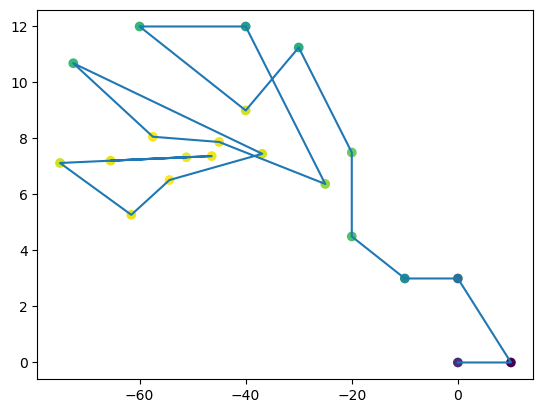

In [134]:
pts = np.stack(points)
vals = np.stack(values)
plt.figure()
plt.plot(pts[:, 0], pts[:,1])
plt.scatter(pts[:, 0], pts[:,1], c=-vals)

In [136]:
res_y = minimize(wrapper_y, [0, 0], method='Nelder-Mead', bounds=[(-180, 180), (-40, 40)], args=(knob_angles_postx),
         options={'initial_simplex': initial_simplex, 'xatol': 5.0, 'fatol': 1e-1, 'disp': True, 'maxiter': 20})

[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-0.9993000000000002
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-1.0247
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-0.9295
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-1.0333
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-0.8939999999999999
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -8

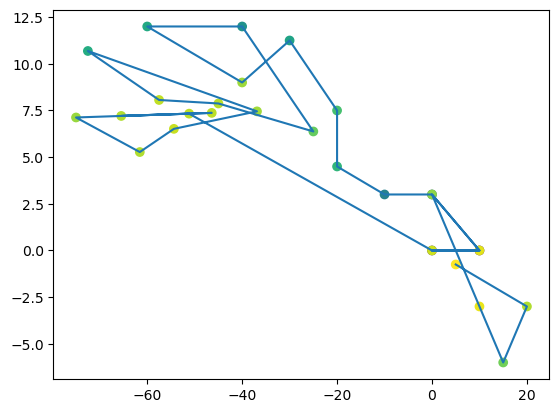

In [137]:
pts = np.stack(points)
vals = np.stack(values)
plt.figure()
plt.plot(pts[:, 0], pts[:,1])
plt.scatter(pts[:, 0], pts[:,1], c=-vals)

In [144]:
knob_angles_posty = knob_angles_postx.copy()
knob_angles_posty[servos_dict['servo_3y']] += anti_forw(*res_y.x)[0] #res.x[0]-res.x[1]
knob_angles_posty[servos_dict['servo_4y']] += anti_forw(*res_y.x)[1]

In [146]:
servos.set_angle(knob_angles_posty)
print('fiber power:',MCP3424_fiber.convert_and_read())

fiber power: 1.052


# Real Setup

In [ ]:
import os
os.chdir("C:\\Users\\simonlab\\Documents\\Bowen\\servoaligner")

import sympy
from sympy import symbols, sin, cos, Add
from sympy import Matrix, nsolve, nsimplify
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

import numpy as np
import matplotlib.pyplot as plt

from expctl.servers.servoaligner.solver_plotter import Optical_system_solver, Mirror, Lens

In [ ]:
#numerical values
#-----------------------------------------------------
#plane 1
#-----------------------------------------------------
#mirror spacing
x1_1 = 0.15
x2_1 = 0.15
x3_1 = 0.15
x4_1 = 0.15
#lens spacing
dy0_1 = 0.1
dy1_1 = 0.4
dy2_1 = 0.15
dy3_1 = 0.15
#focal length
fl1_1 = 0.3
fl2_1 = 0.1
fl3_1 = 1
#MOT and Cavity
MOT_pos_1=1e-3
Cav_pos_1=-1e-3

#-----------------------------------------------------
#plane 2
#-----------------------------------------------------
#mirror spacing
x1_2 = 0.15
x2_2 = 0.15
x3_2 = 0.15
x4_2 = 0.15
#lens spacing
dy0_2 = 0.1
dy1_2 = 0.4
dy2_2 = 0.15
dy3_2 = 0.15
#focal length
fl1_2 = 0.3
fl2_2 = 0.1
fl3_2 = 1
#MOT and Cavity
MOT_pos_2=5e-4
Cav_pos_2=-5e-4

MOT_Cav_dist = 0.04

params_1={'x1':x1_1, 'x2':x2_1, 'x3': x3_1, 'x4':x4_1, 'dy0':dy0_1, 'dy1':dy1_1, 'dy2': dy2_1, 'dy3': dy3_1, 'fl1': fl1_1, 'fl2': fl2_1, 'fl3': fl3_1, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos': MOT_pos_1, 'Cav_pos': Cav_pos_1}
params_2={'x1':x1_2, 'x2':x2_2, 'x3': x3_2, 'x4':x4_2, 'dy0':dy0_2, 'dy1':dy1_2, 'dy2': dy2_2, 'dy3': dy3_1, 'fl1': fl1_2, 'fl2': fl2_2, 'fl3': fl3_2, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos': MOT_pos_2, 'Cav_pos': Cav_pos_2}

In [ ]:
%matplotlib inline
solver_0=Optical_system_solver()
solver_0.init_ray_length=0.2
solver_0.xy=0
solver_0.plot_size=(10,10)
Mrr1_1, Mrr2_1, Mrr3_1, Mrr4_1 = solver_0.real_setup_solver_1(params=params_1, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=0)
solver_1=Optical_system_solver()
solver_1.init_ray_length=0.2
solver_1.xy=1
solver_1.plot_size=(10,10)
Mrr1_2, Mrr2_2, Mrr3_2, Mrr4_2 = solver_1.real_setup_solver_2(params=params_1, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=0)
Mrr_list=[Mrr1_1, Mrr2_1, Mrr3_1, Mrr4_1, Mrr1_2, Mrr2_2, Mrr3_2, Mrr4_2]
for Mrr in Mrr_list:
    print(Mrr.knob_deg())

KeyError: 'MOT_pos_1'

In [1]:
# import os
# os.chdir('//Users//libowen//Desktop//servoserver//servotest//src')
import os
os.chdir("C:\\Users\\simonlab\\Documents\\Bowen\\servo_np\\servotest\\src\\expctl\\servers\\servoaligner")

import sympy
from sympy import symbols, sin, cos
from sympy import Matrix, nsolve
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

import xarray as xr

import multiprocessing
import os
import time
from tqdm import tqdm
import numpy as np

from solver_plotter import Optical_system_solver, Mirror, Lens

In [2]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.35
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=2e-5

MOT_pos_2=0
Cav_pos_2=2e-5

MOT_pos_rel = 0.2
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

In [3]:
%matplotlib qt
solver_0=Optical_system_solver()
solver_0.init_ray_length=0.2

Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver_y(params=params, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=1)
print([Mrr1_y.tl, Mrr2_y.tl, Mrr3_y.tl, Mrr4_y.tl])
solver_0.plot_size=(6,10)
Mrr1_x, Mrr2_x, Mrr3_x, Mrr4_x = solver_0.default_setup_solver(params=params, tl_list=[0, 0, 0, 0], comp_list=[Mrr1_y.tl, Mrr2_y.tl, Mrr3_y.tl, Mrr4_y.tl], plot_switch=1)
knob_deg_list=[Mrr1_x.knob_deg(), Mrr1_y.knob_deg(), Mrr2_x.knob_deg(), Mrr2_y.knob_deg(), Mrr3_x.knob_deg(), Mrr3_y.knob_deg(), Mrr4_x.knob_deg(), Mrr4_y.knob_deg()]
print(knob_deg_list)

[0.00029327324244253933, -0.0002932729240254635, 0.00016137148163717196, -0.00019546196044814023]
2200.00000000085
[15.79091387155735, 13.725188139808303, 15.790755399801299, -13.725173237887873, 10.460491762239851, 7.552185406174519, 12.296076495156584, -9.147619865469055]


In [2]:
# import os
# os.chdir('//Users//libowen//Desktop//servoserver//servotest//src')
import os
os.chdir("C:\\Users\\simonlab\\Documents\\Bowen\\servo_np\\servotest\\src\\expctl\\servers\\servoaligner")

import xarray as xr

import multiprocessing
import os
import time
from tqdm import tqdm
import numpy as np

from solver_plotter_np import Optical_system_solver, Mirror, Lens
from model_setting import params

In [8]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.35
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=-2e-4

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.2
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

In [9]:
%matplotlib qt
solver_0=Optical_system_solver()
solver_0.init_ray_length=0.2

Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver_y(params=params, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=1)
solver_0.plot_size=(6,10)
Mrr1_x, Mrr2_x, Mrr3_x, Mrr4_x = solver_0.default_setup_solver(params=params, tl_list=[0, 0, 0, 0], comp_list=[Mrr1_y.tl, Mrr2_y.tl, Mrr3_y.tl, Mrr4_y.tl], plot_switch=1)
knob_deg_list=[Mrr1_x.knob_deg(), Mrr1_y.knob_deg(), Mrr2_x.knob_deg(), Mrr2_y.knob_deg(), Mrr3_x.knob_deg(), Mrr3_y.knob_deg(), Mrr4_x.knob_deg(), Mrr4_y.knob_deg()]
print(knob_deg_list)

[-137.30526030334718, 0.0, -137.30525514968568, 0.0, -90.95589399274054, 0.0, -106.91050131756886, 0.0]


In [5]:
servos_dict={'servo_1x':0, 'servo_1y':1, 'servo_2x':2, 'servo_2y':3, 'servo_3x':4, 'servo_3y':5, 'servo_4x':6, 'servo_4y':7}
n_list=['servo_1x','servo_1y']

# Camera Function